# K-Nearest Neighbors (KNN) for Shopping Preference Prediction

In this notebook we explore K-Nearest Neighbors (KNN), a powerful instance-based learning algorithm used for classification and regression.

Our objective is to predict a customer’s shopping preference:
- Online
- Store
- Hybrid

using behavioral, digital engagement, and purchasing psychology features.

This notebook covers:
1. Mathematical intuition behind KNN
2. Bias vs Variance behavior
3. When to use KNN
4. When not to use KNN
5. Hyperparameter tuning
6. Implementation using Scikit-Learn
7. Model evaluation and interpretation

The notebook integrates the project’s modular ML pipeline:
- src/data_loader.py
- src.features.py
- src.preprocess.py

In [56]:
# Setup
import sys
sys.path.append("..")

# Import Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV

# project modules
from src.data_loader import load_raw_data
from src.preprocess import preprocess_dataset

sns.set(style="whitegrid")

## Loading the Dataset

We load the dataset using our centralized data loading utility.

In [57]:
dataset_name = "online vs store shopping dataset.csv"

df = load_raw_data(dataset_name)

df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


## Data Preprocessing

We apply the preprocessing pipeline defined in `src/preprocess.py`.

This pipeline performs:

1. Feature engineering
2. Train/test split
3. Feature scaling
4. Categorical encoding

In [58]:
X_train, X_test, y_train, y_test, preprocessor = preprocess_dataset(
    df,
    target_column="shopping_preference"
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (9431, 34)
Test shape: (2358, 34)


# Mathematical Intuition of K-Nearest Neighbors

KNN is a **non-parametric, instance-based learning algorithm**.

Instead of learning a model during training, KNN **stores the training data** and makes predictions based on similarity.

Steps for prediction:

1. Choose **K**, the number of neighbors
2. Compute the **distance** between the new point and all training points
3. Select the **K closest neighbors**
4. Use **majority voting** to determine the predicted class

Distance is typically measured using **Euclidean distance**:

d(x, y) = √ Σ (xi − yi)²

The predicted class is the one that appears **most frequently among the K neighbors**.

# Bias vs Variance Tradeoff

KNN behavior strongly depends on **K**.

Small K:

- Very flexible model
- Low bias
- High variance
- Can overfit

Large K:

- Simpler model
- Higher bias
- Lower variance
- Smoother decision boundary

Choosing the right **K** is critical.

# When to Use KNN

KNN works well when:

✔ Dataset size is relatively small  
✔ Feature space is meaningful  
✔ Similar observations have similar labels  
✔ Decision boundary is nonlinear  

Common applications:

- Recommendation systems
- Image recognition
- Anomaly detection

# When NOT to Use KNN

KNN struggles when:

❌ Dataset is very large  
❌ Feature space is very high-dimensional  
❌ Many irrelevant features exist  
❌ Real-time prediction is required

Why?

Because KNN must compute **distance to every training sample** during prediction.

## Training the Baseline Model

In [59]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [60]:
predictions = knn.predict(X_test)

## Model Evaluation

In [61]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("F1 Score:", f1_score(y_test, predictions, average="weighted"))

print("\nClassification Report:\n")

print(classification_report(y_test, predictions))

Accuracy: 0.8922815945716709
F1 Score: 0.8677618252074067

Classification Report:

              precision    recall  f1-score   support

      Hybrid       0.00      0.00      0.00        74
      Online       0.78      0.32      0.46       235
       Store       0.91      0.99      0.95      2049

    accuracy                           0.89      2358
   macro avg       0.56      0.44      0.47      2358
weighted avg       0.87      0.89      0.87      2358



## Confusion Matrix

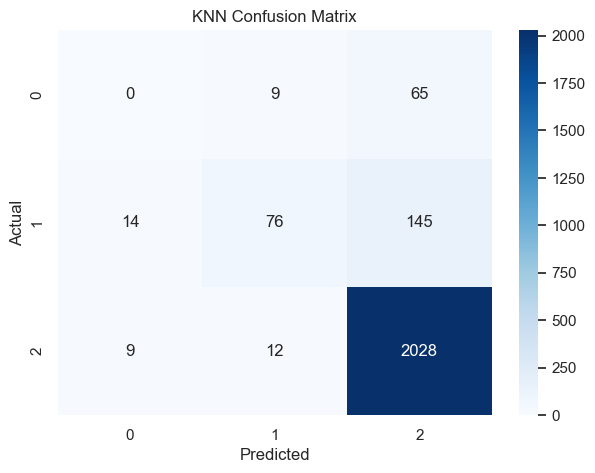

In [62]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("KNN Confusion Matrix")

plt.ylabel("Actual")

plt.xlabel("Predicted")

plt.show()

# Hyperparameter Tuning

Important KNN hyperparameters:

| Parameter | Meaning |
|--------|--------|
| n_neighbors | Number of neighbors |
| weights | Uniform vs distance weighting |
| metric | Distance metric |

Choosing the correct **K value** significantly impacts performance.

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

param_grid = {
    "n_neighbors": [3,5,7,9,11,15],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train_encoded)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}


In [64]:
best_knn = grid.best_estimator_

predictions = best_knn.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      Hybrid       0.18      0.05      0.08        74
      Online       0.85      0.34      0.48       235
       Store       0.91      0.99      0.95      2049

    accuracy                           0.90      2358
   macro avg       0.65      0.46      0.50      2358
weighted avg       0.88      0.90      0.87      2358



# Understanding the Effect of K

To understand how the number of neighbors affects performance,
we visualize the validation score across different values of K.

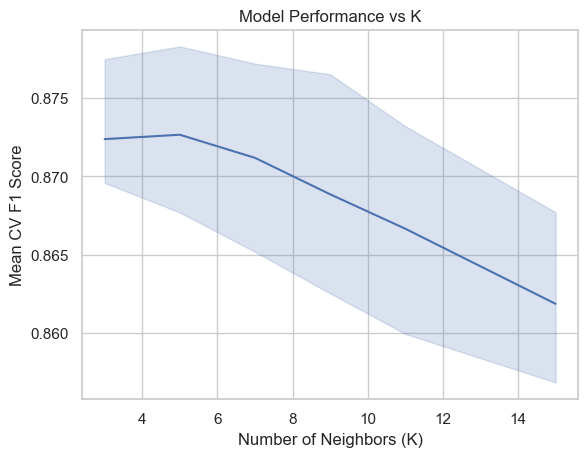

In [65]:
results = pd.DataFrame(grid.cv_results_)

sns.lineplot(
    data=results,
    x="param_n_neighbors",
    y="mean_test_score"
)

plt.title("Model Performance vs K")

plt.xlabel("Number of Neighbors (K)")

plt.ylabel("Mean CV F1 Score")

plt.show()

# Key Insights

KNN captures **local similarity patterns** in the data.

Observations:

- Customers with similar digital engagement patterns
  tend to share similar shopping preferences.

- Behavioral features such as
  `online_order_ratio` and `online_spend_ratio`
  strongly influence neighborhood similarity.

- Choosing an optimal **K** balances overfitting and underfitting.

# Logistic Regression vs KNN

| Model | Type |
|------|------|
| Logistic Regression | Linear |
| KNN | Non-parametric |

Logistic Regression:

- Fast
- Interpretable
- Linear decision boundary

KNN:

- Flexible
- Captures nonlinear patterns
- Slower at prediction time

# Next Models to Explore

The next models in our machine learning pipeline:

- Decision Trees
- Random Forest
- Gradient Boosting
- Support Vector Machines
- Naive Bayes

These models can capture **more complex relationships** in the data.